# N-armed Bandits

In [1]:
import numpy as np
from scipy import stats
import random
import matplotlib.pyplot as plt

In [2]:
# Contants
n_arms = 10
probs = np.random.rand(n_arms) #1D array of win probs associated with each machine
eps = 0.2

In [4]:
def get_reward(prob, n=10):
    reward = 0
    for i in range(n):
        if random.random() < prob:
            reward += 1
    return reward

### Update Rule for an Arm

$$
\mu_{\text{new}} = \frac{k\mu_{\text{old}} + x}{k+1}
$$

Where:

* $\mu_{\text{new}}$: updated mean reward
* $\mu_{\text{old}}$: current estimated mean reward
* $k$: number of values observed
* $x$: newly observed reward


In [12]:
def update_record(record, arm_idx, reward):
    n = record[arm_idx][0]
    mean = record[arm_idx][1]

    new_mean = (n * mean + reward) / (n + 1)

    record[arm_idx][0] += 1
    record[arm_idx][1] = new_mean

    return record


def get_best_arm(record):
    return np.argmax(record[:, 1], axis=0)


### Epsilon Greedy Policy

In [14]:
def epsilon_greedy(record, eps = 0.1):
    if np.random.random() <= eps:
        # explore
        return np.random.randint(n_arms)
    else:
        # exploit
        return get_best_arm(record)

### Epsilon Greedy: Mean Reward

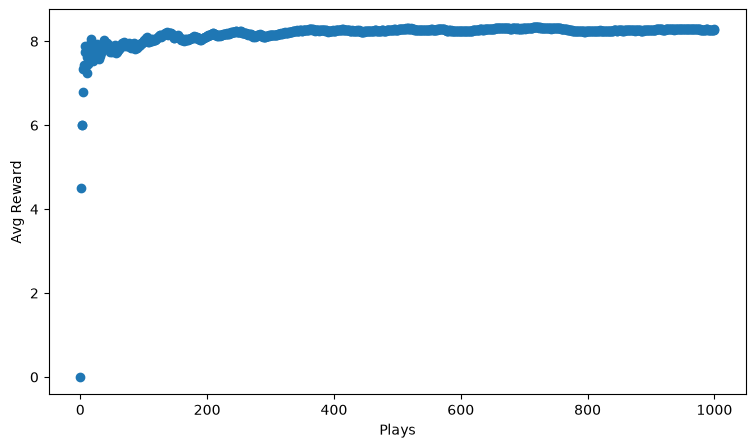

In [28]:
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)
record = np.zeros((n_arms, 2)) # arm ---- [k, curr_mean]
n_plays = 1e3
rewards = [0]

for i in range(int(n_plays)):
    arm = epsilon_greedy(record, eps=0.3)
    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i +1) * rewards[-1] + r) / (i + 2)

    rewards.append(mean_reward)

ax.scatter(np.arange(len(rewards)), rewards)

### Epsilon Greedy: Different Values of Epsilon

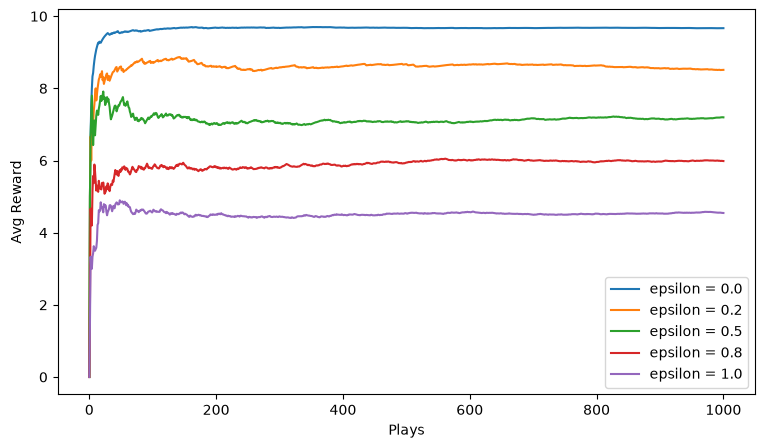

In [31]:
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)

n_plays = 1e3

epsilons = np.linspace(0, 1, 5)

for eps in epsilons:
    rewards = [0]
    record = np.zeros((n_arms, 2)) # arm ---- [k, curr_mean]
    for i in range(int(n_plays)):
        arm = epsilon_greedy(record, eps=eps)
        r = get_reward(probs[arm])
        record = update_record(record, arm, r)

        mean_reward = ((i +1) * rewards[-1] + r) / (i + 2)

        rewards.append(mean_reward)

    ax.plot(rewards, label=f'epsilon = {eps:.1f}')
ax.legend()

### Softmax Policy

$$
P(A) =
\frac{
\exp\left(\frac{Q_k(A)}{\tau}\right)
}{
\displaystyle\sum_{i=1}^{n}
\exp\left(\frac{Q_k(i)}{\tau}\right)
}
$$

Where:

* $P(A)$: probability of selecting arm (A)
* $Q_k(A)$: estimated value of arm (A) after (k) observations
* $\tau$: temperature parameter controlling exploration
* $n$: total number of arms
* $i$: index of each arm


In [42]:
def softmax(vals, temperature=1.12):
    z = vals / temperature
    z = z - np.max(z)

    probs = np.exp(z) / np.sum(np.exp(z))

    return probs

In [34]:
def softmax_policy(record, temperature):
    probs = softmax(record[:, 1], temperature=temperature)
    arm = np.random.choice(np.arange(n_arms), p=probs)
    return arm

### Softmax Policy: Mean Reward

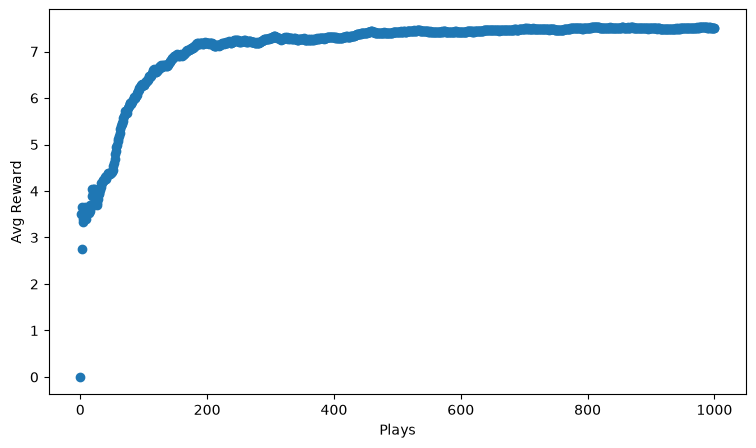

In [51]:
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)
record = np.zeros((n_arms, 2)) # arm ---- [k, curr_mean]
n_plays = 1e3
rewards = [0]
temperature = 2

for i in range(int(n_plays)):
    arm = softmax_policy(record, temperature=temperature)
    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i +1) * rewards[-1] + r) / (i + 2)

    rewards.append(mean_reward)

ax.scatter(np.arange(len(rewards)), rewards)

### Softmax Policy with temperature decay: Mean Reward

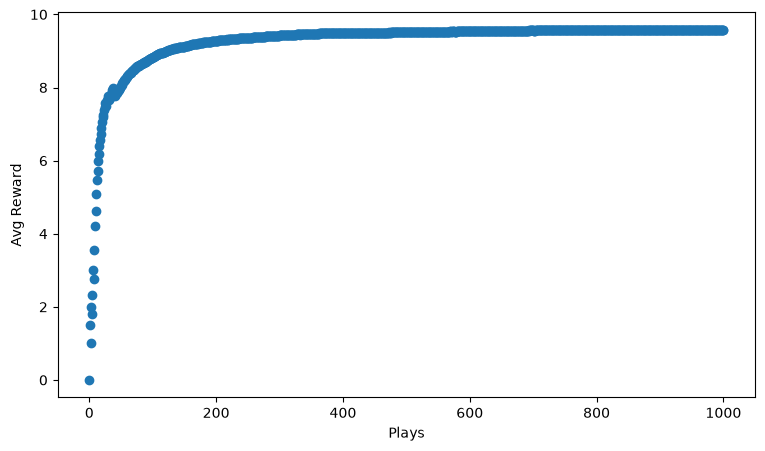

In [53]:
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)
record = np.zeros((n_arms, 2)) # arm ---- [k, curr_mean]
n_plays = 1e3
rewards = [0]
temperature = 2
t_decay = 0.9900

T = temperature
for i in range(int(n_plays)):
    arm = softmax_policy(record, temperature=T)
    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i +1) * rewards[-1] + r) / (i + 2)

    rewards.append(mean_reward)

    T = max(T * t_decay, 0.01)

ax.scatter(np.arange(len(rewards)), rewards)

### Softmax Policy: Different decay rates

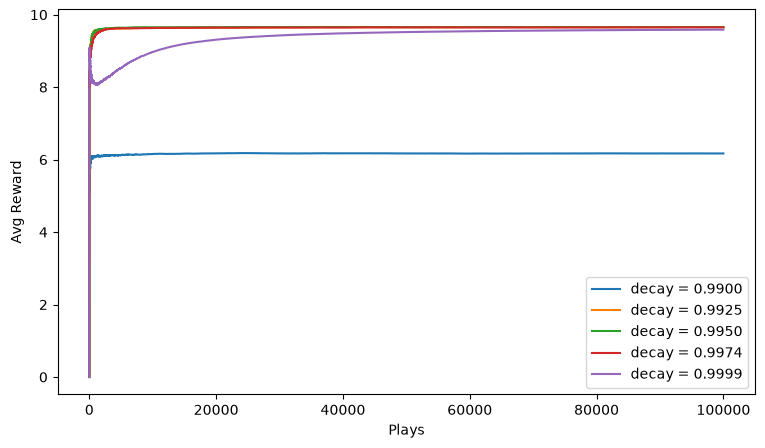

In [54]:
fig, ax = plt.subplots(1, 1)

ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)

n_plays = 1e5
temperature = 2

t_decays = np.linspace(0.99, 0.9999, 5)

for t_decay in t_decays:

    record = np.zeros((n_arms, 2))
    rewards = [0]

    T = temperature

    for i in range(int(n_plays)):
        arm = softmax_policy(record, temperature=T)

        r = get_reward(probs[arm])
        record = update_record(record, arm, r)

        mean_reward = ((i + 1) * rewards[-1] + r) / (i + 2)
        rewards.append(mean_reward)

        T = max(T * t_decay, 0.01)

    ax.plot(rewards, label=f"decay = {t_decay:.4f}")

ax.legend()

### Softmax policy with temperature decay vs Vanilla Softmax policy

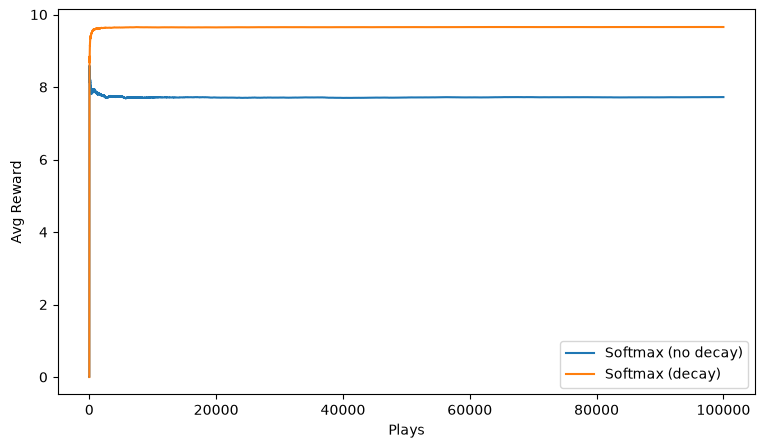

In [55]:
fig, ax = plt.subplots(1, 1)

ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)

n_plays = 1e5

temperature = 2
t_decay = 0.995


# Softmax — no decay
record = np.zeros((n_arms, 2))
rewards_no_decay = [0]

for i in range(int(n_plays)):
    arm = softmax_policy(record, temperature=temperature)

    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i + 1) * rewards_no_decay[-1] + r) / (i + 2)
    rewards_no_decay.append(mean_reward)


# Softmax — with decay
record = np.zeros((n_arms, 2))
rewards_decay = [0]

T = temperature

for i in range(int(n_plays)):
    arm = softmax_policy(record, temperature=T)

    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i + 1) * rewards_decay[-1] + r) / (i + 2)
    rewards_decay.append(mean_reward)

    T = max(T * t_decay, 0.01)


# Plot
ax.plot(rewards_no_decay, label="Softmax (no decay)")
ax.plot(rewards_decay, label="Softmax (decay)")

ax.legend()

### Softmax Policy vs Epsilon Greedy

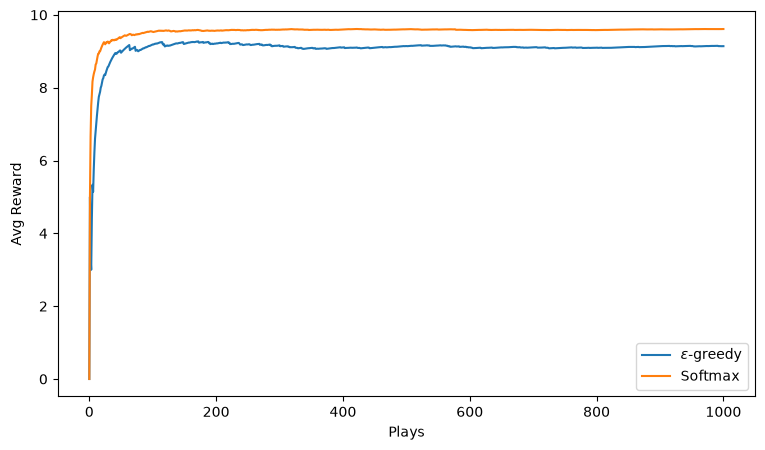

In [60]:
fig, ax = plt.subplots(1, 1)

ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)

n_plays = 1e3
temperature = 1.12
eps = 0.1

# Epsilon-greedy
record = np.zeros((n_arms, 2))
rewards_eps = [0]

for i in range(int(n_plays)):
    arm = epsilon_greedy(record, eps=eps)

    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i + 1) * rewards_eps[-1] + r) / (i + 2)
    rewards_eps.append(mean_reward)


# Softmax
record = np.zeros((n_arms, 2))
rewards_softmax = [0]

for i in range(int(n_plays)):
    arm = softmax_policy(record, temperature=temperature)

    r = get_reward(probs[arm])
    record = update_record(record, arm, r)

    mean_reward = ((i + 1) * rewards_softmax[-1] + r) / (i + 2)
    rewards_softmax.append(mean_reward)


# Plot both
ax.plot(rewards_eps, label=r"$\epsilon$-greedy")
ax.plot(rewards_softmax, label="Softmax")

ax.legend()